In [1]:
from umap import UMAP
import pandas as pd
import numpy as np
from sklearn.preprocessing import MinMaxScaler, RobustScaler
from sklearn.utils import resample
from sklearn.metrics import pairwise_distances
from scipy.spatial.transform import Rotation as R
from pyDRMetrics.pyDRMetrics import *
from scipy.stats import wilcoxon
from itertools import product
from joblib import Parallel, delayed
from pathlib import Path
import plotly.express as px
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.io as pio
pio.renderers.default = "browser"

# Change working directory
import os
os.chdir(os.getcwd() + "/../")

import config
import hyp_config
from visualisation.plotting import plot_embedding, plot_interactive_embedding

# UMAP Hyperparameter Investigation
The parameters were selected such that the dimensionality-reduced space exhibits a distinct topology. Main parameters to tune:
- **min_dist**: Increasing the minimum distance between points caused the data points to spread further apart diluting finer topologies. 
- **n_neighbors**: A lower number of neighbours led to a more curled up structure while a higher number unfolded it. Increasing the parameter to more than 20 did not further change the embedding significantly.
- **n_components**: The number of dimensions of the embedding.

In [2]:
# Load data
df_minmax = pd.read_csv(f"{config.output_dir}wide_table_knn_minmax.csv")
df_robust = pd.read_csv(f"{config.output_dir}wide_table_knn_robust.csv")
df_dict = {"minmax": df_minmax, "robust": df_robust}

# Scale data
minmax_scaler = MinMaxScaler().fit(df_minmax[config.parameters])
X_m = pd.DataFrame(minmax_scaler.transform(df_minmax[config.parameters]), columns=config.parameters)

# Robust scaler
robust_scaler = RobustScaler().fit(df_robust[config.parameters])
X_r = pd.DataFrame(robust_scaler.transform(df_robust[config.parameters]), columns=config.parameters)

X_dict = {"minmax": X_m, "robust": X_r}

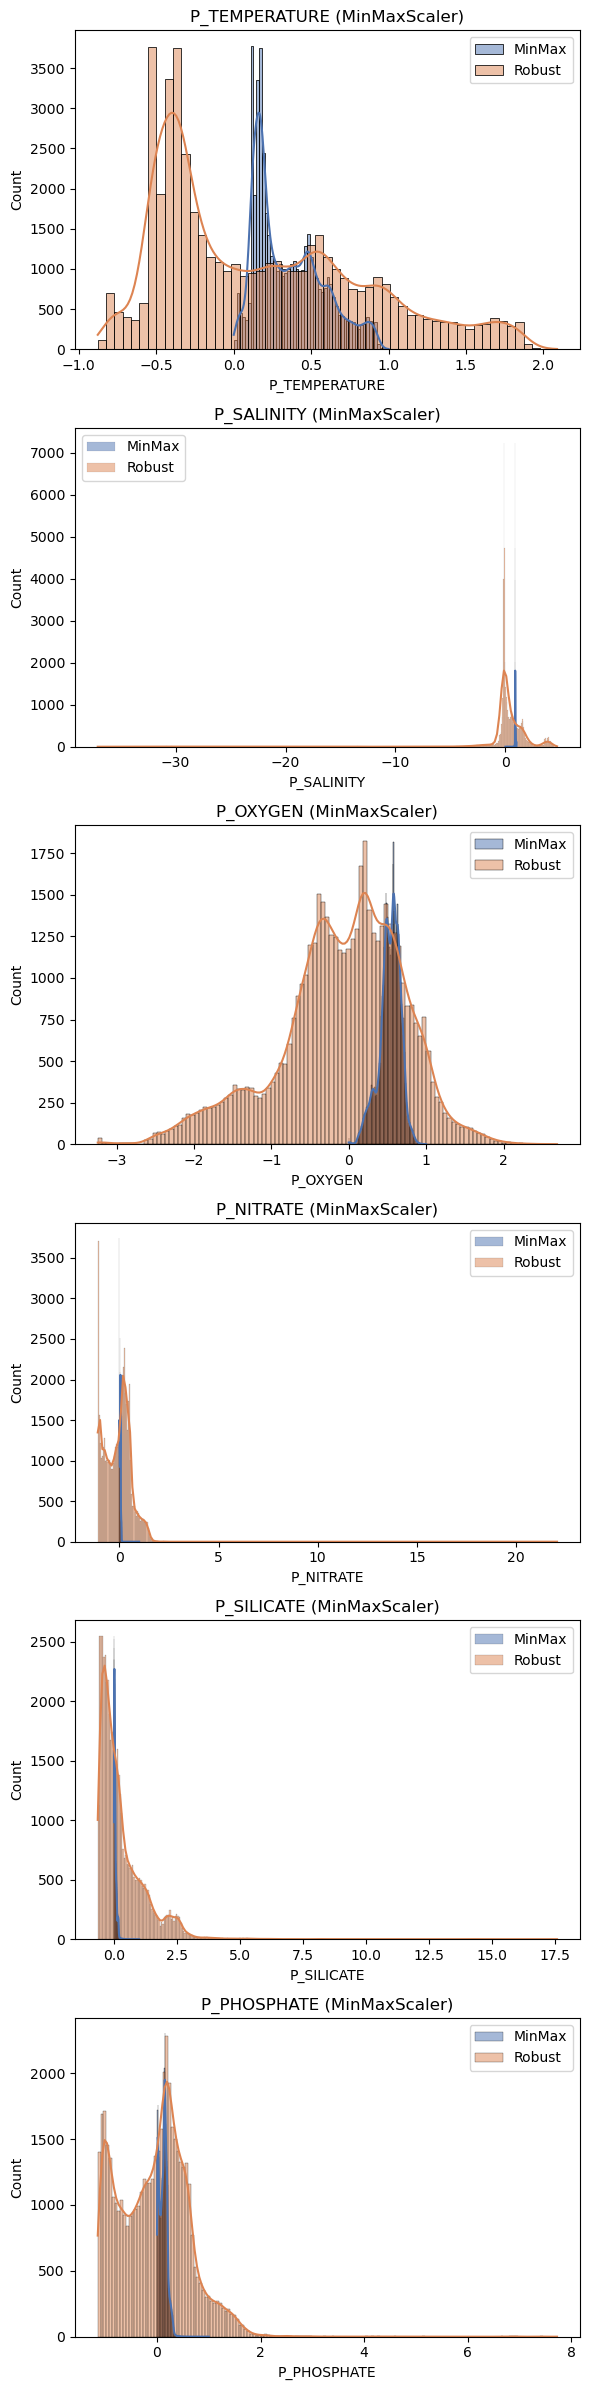

In [3]:
# Compare scald distributions
fig, axes = plt.subplots(nrows=len(config.parameters), ncols=1, figsize=(6, 4 * len(config.parameters)))

for i, feature in enumerate(config.parameters):
    sns.histplot(X_dict["minmax"][feature], ax=axes[i], color="#4C72B0", kde=True, label="MinMax")
    sns.histplot(X_dict["robust"][feature], ax=axes[i], color="#DD8452", kde=True, label="Robust")
    axes[i].set_title(f"{feature} (MinMaxScaler)")
    axes[i].legend()

plt.tight_layout()
plt.show()

# Compute Metrics

In [4]:
def umap_grid_search(X_in, param_grid, subsample_size_metrics=2000, iteration=0, scaler_name="minmax", out_dir="umap_metrics_report", n_jobs=-1):
    """ Perform grid search over hyperparameters for UMAP, store results (diagrams and CSV) in the specified directory, and plot Shepard Diagram. """
    # Create output dir if it does not exist yet
    Path(out_dir).mkdir(parents=True, exist_ok=True)

    # Prepare parameter combinations
    param_combinations = [dict(zip(param_grid.keys(), v)) for v in product(*param_grid.values())]

    # Subsample once for metrics
    X_metrics = resample(X_in, n_samples=subsample_size_metrics)  # , random_state=random_state)

    def evaluate_umap(umap_hyps):  # n_neighbors, min_dist, metric):
        # Compute embedding
        umap_model = UMAP(**umap_hyps)
        embedding = umap_model.fit_transform(X_metrics)
        try:
            Xr = umap_model.inverse_transform(embedding)
        except:
            Xr = None  # Some UMAP configurations don't support inverse_transform

        # Compute metrics
        drm = DRMetrics(X_metrics, embedding, Xr)

        return {**umap_hyps, **{"Qlocal": drm.Qlocal, "Qglobal": drm.Qglobal, "AUC_T": drm.AUC_T, "AUC_C": drm.AUC_C, "iteration": iteration, "scaler": scaler_name}}

    # Parallel execution
    print(f"Running UMAP grid search on {len(param_combinations)} configurations...")
    results = Parallel(n_jobs=n_jobs)(
        delayed(evaluate_umap)(h) for h in tqdm(param_combinations, position=0, leave=True, desc="UMAP Evaluation")
    )

    # Save results
    df = pd.DataFrame(results)
    df.to_csv(f"{out_dir}/umap_grid_metrics_exp{scaler_name}_iteration{iteration}.csv", index=False)

    print(f"Grid search complete. Results saved in '{out_dir}'\n")

    return df


In [5]:
def plot_shepard(X_sub, y_sub, save_as=None, dpi=300, figsize=(6, 6)):
    """ Plot Shepard diagram. """

    # Compute pairwise distances
    D_high = pairwise_distances(X_sub)
    D_low = pairwise_distances(y_sub)

    # Compute correlation
    corr = round(np.corrcoef(D_high, D_low).mean(), 2)
    print(f"Mean correlation between high and low dimenaionsal distances: {corr}")

    # Plot
    plt.figure(figsize=figsize)
    plt.scatter(D_high.flatten(), D_low.flatten(), alpha=0.1, s=1)
    plt.plot([D_high.min(), D_high.max()], [D_high.min(), D_high.max()], "r--")
    plt.xlabel("Original Distances")
    plt.ylabel("UMAP Distances")
    plt.title(f"Shepard Diagram")
    plt.tight_layout()
    if save_as:
        plt.savefig(save_as, dpi=dpi)
    plt.show()

    
def plot_qs(df_display, out_dir):
    """ Qlocal vs Qglobal plot. """
    plt.figure(figsize=(8, 6))
    sns.scatterplot(data=df_display, x="Qglobal", y="Qlocal", hue="metric", style="min_dist", size="n_neighbors", palette="tab10")
    plt.xlabel("Qglobal")
    plt.ylabel("Qlocal")
    plt.title("UMAP Hyperparameter Grid: Qlocal vs Qglobal")
    plt.legend(bbox_to_anchor=(1.05, 1), loc="upper left")
    plt.tight_layout()
    plt.savefig(out_dir + "/q_scores.png")
    plt.show()


def plot_qs_interactive(df_display, out_dir):
    """ Interactive scatter Qlocal vs. Qglobal plot.  """
    fig = px.scatter(
        df_display,
        x="Qglobal",
        y="Qlocal",
        color="metric",
        size="n_neighbors",
        symbol="min_dist",
        title="Qlocal vs Qglobal by UMAP parameters",
        color_discrete_sequence=px.colors.qualitative.Set2,
    )
    
    # Update layout for axis labels and margins
    fig.update_layout(
        xaxis=dict(title="Qglobal"),
        yaxis=dict(title="Qlocal"),
        legend_title="Metric",
        margin=dict(l=40, r=40, t=40, b=40),
        width=1000, height=1000
    )
    
    fig.write_html(out_dir + "/q_scores.html")
    fig.show() 


In [ ]:
df_results = []

for i in range(10): 
    for scaler_name, X in X_dict.items():
        print(scaler_name)
        X = X.to_numpy()
    
        df_results.append(umap_grid_search(X,
            param_grid={
                "n_neighbors": [5, 10, 20, 30, 50, 100, 150],
                "min_dist":  [0.0, 0.001, 0.01, 0.05, 0.1, 0.3, 0.5, 0.8, 0.99],
                "metric": ["euclidean", "mahalanobis", "manhattan", "cosine", "chebyshev"],
                "n_components": [3]
            },
            iteration=i,
            scaler_name=scaler_name,
            subsample_size_metrics=2000,
            out_dir=f"{config.output_dir_umap}/{scaler_name}",
            n_jobs=4  # Use -1 for all cores
        ))

# Assemble and store results
df_results = pd.concat(df_results)
df_results.to_csv(f"{config.output_dir_umap}/umap_grid_metrics.csv", index=False)

# Compare Scalers

In [6]:
# Load score results
df = pd.read_csv(f"{config.output_dir_umap}/umap_grid_metrics.csv")

In [7]:
# Check if differences between minmax and robust scaler are statistically significant
metrics = ["Qlocal", "Qglobal", "AUC_T", "AUC_C"]
for metric in metrics:
    print(f"\nComparing {metric}:")
    try:
        stat, p = wilcoxon(df[df.scaler == "minmax"][metric], df[df.scaler == "robust"][metric])
        print(f"Wilcoxon test: W={stat:.3f}, p={p:.4f}")
    except ValueError:
        print("Wilcoxon test could not be performed (not enough non-zero differences).")


Comparing Qlocal:
Wilcoxon test: W=18734.000, p=0.0000

Comparing Qglobal:
Wilcoxon test: W=59210.000, p=0.0000

Comparing AUC_T:
Wilcoxon test: W=12169.000, p=0.0000

Comparing AUC_C:
Wilcoxon test: W=428561.000, p=0.0000


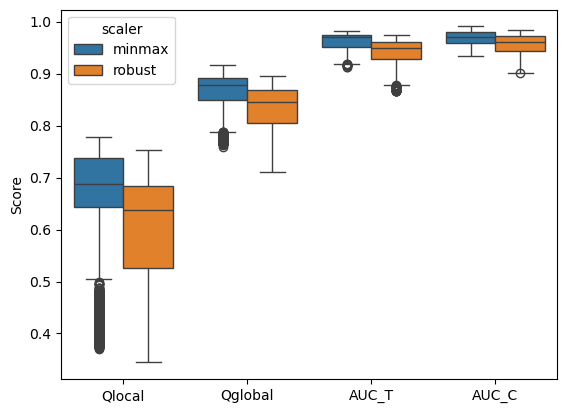

In [8]:
# Overall comparison across validation metrics
melted = df.melt(
    id_vars=['scaler', 'iteration', 'n_neighbors', 'min_dist', 'metric', 'n_components'],
    value_vars=metrics,
    var_name='val_metric',
    value_name='score')

sns.boxplot(melted, x="val_metric", y="score", hue="scaler")
plt.ylabel("Score")
plt.xlabel("")
plt.show()

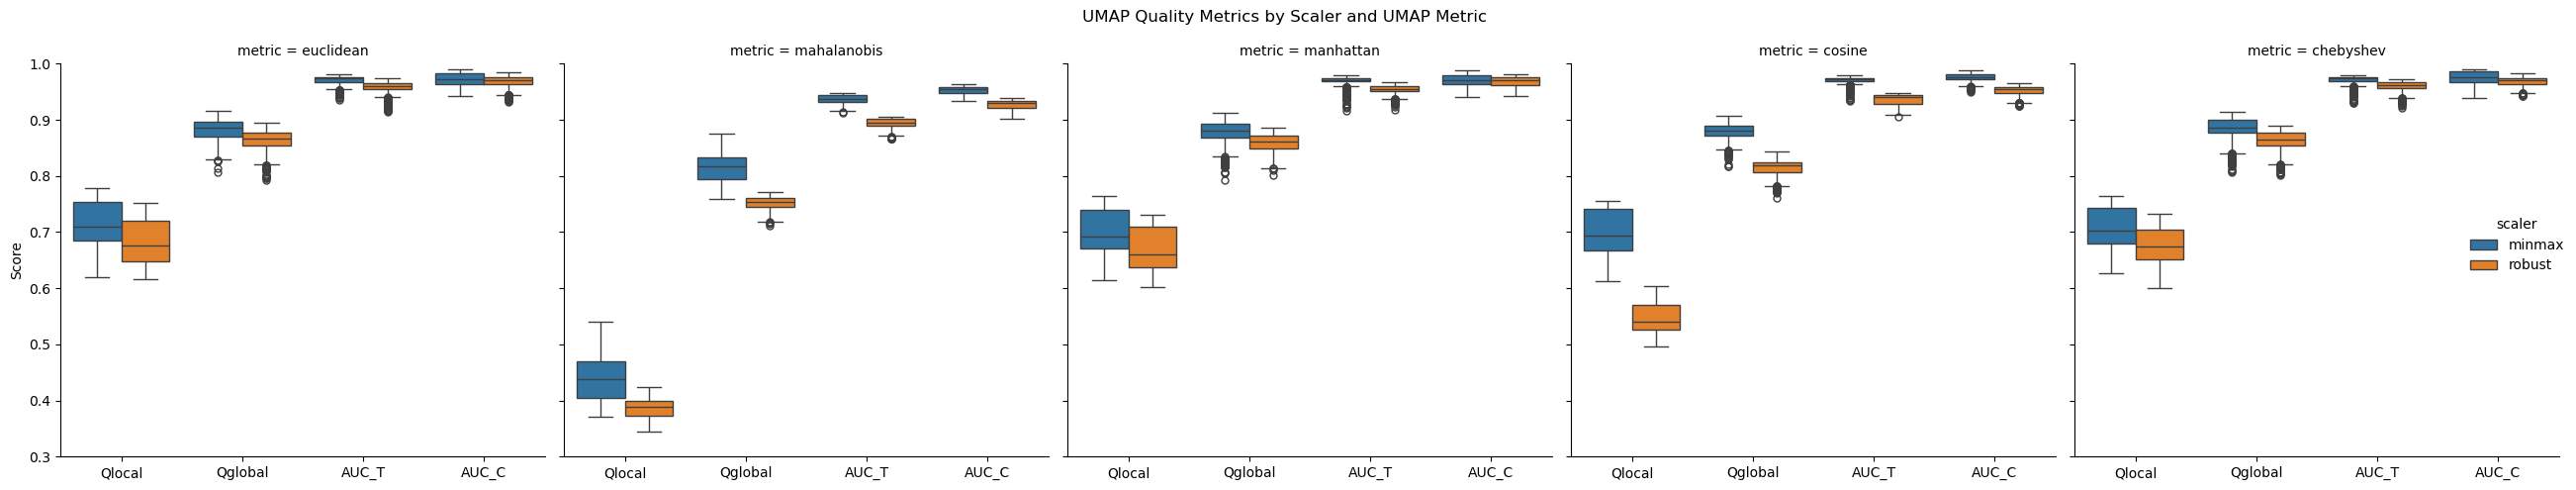

In [9]:
# Overall comparison across validation metrics per distance metric
g = sns.catplot(melted, kind="box",
    x="val_metric",
    y="score",
    hue="scaler",
    col="metric", errorbar='sd')

g.fig.subplots_adjust(top=0.85)
g.fig.suptitle("UMAP Quality Metrics by Scaler and UMAP Metric")
g.set_axis_labels("", "Score")
g.set(ylim=(np.floor(melted.score.min()*10)/10, 1.0))
plt.tight_layout()

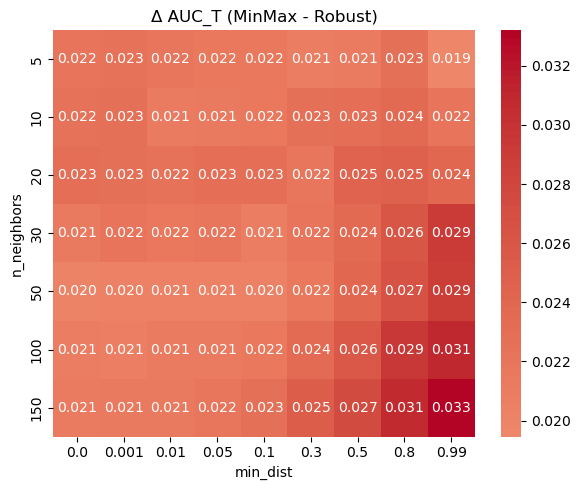

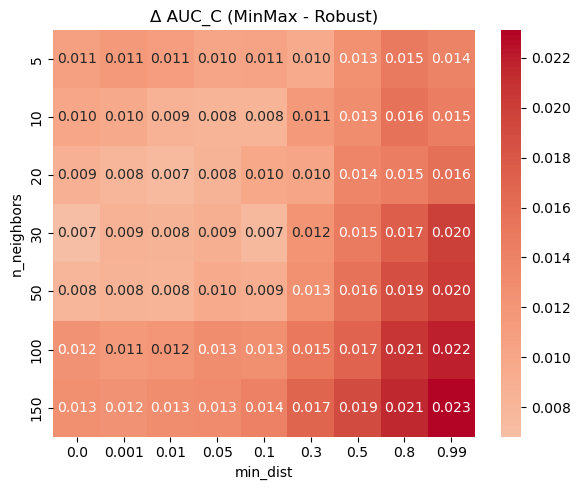

In [10]:
# Compare AUC_C and AUC_T
df_wide = df.pivot_table(
    index=["iteration", "n_neighbors", "min_dist", "metric", "n_components"],
    columns="scaler",
    values=["AUC_T", "AUC_C"]
)

df_wide.columns = [f"{metric}_{scaler}" for metric, scaler in df_wide.columns]
df_wide = df_wide.reset_index()

# Compute differences 
df_wide['delta_AUC_T'] = df_wide['AUC_T_minmax'] - df_wide['AUC_T_robust']
df_wide['delta_AUC_C'] = df_wide['AUC_C_minmax'] - df_wide['AUC_C_robust']

# Compute mean
agg = df_wide.groupby(["n_neighbors", "min_dist"], as_index=False).mean(numeric_only=True)

# Plot
for metric in ["AUC_T", "AUC_C"]:
    pivot = agg.pivot(index="n_neighbors", columns="min_dist", values=f"delta_{metric}")
    plt.figure(figsize=(6, 5))
    sns.heatmap(pivot, cmap="coolwarm", center=0, annot=True, fmt=".3f")
    plt.title(f"Δ {metric} (MinMax - Robust)")
    plt.xlabel("min_dist")
    plt.ylabel("n_neighbors")
    plt.tight_layout()
    plt.show()

Conclusion: On average and across all distance metrics, the embeddings computed on min-max scaled data outperformed embeddings computed on robustly scaled data. The differences are statistically significant.

# Select Hyperparameters

minmax


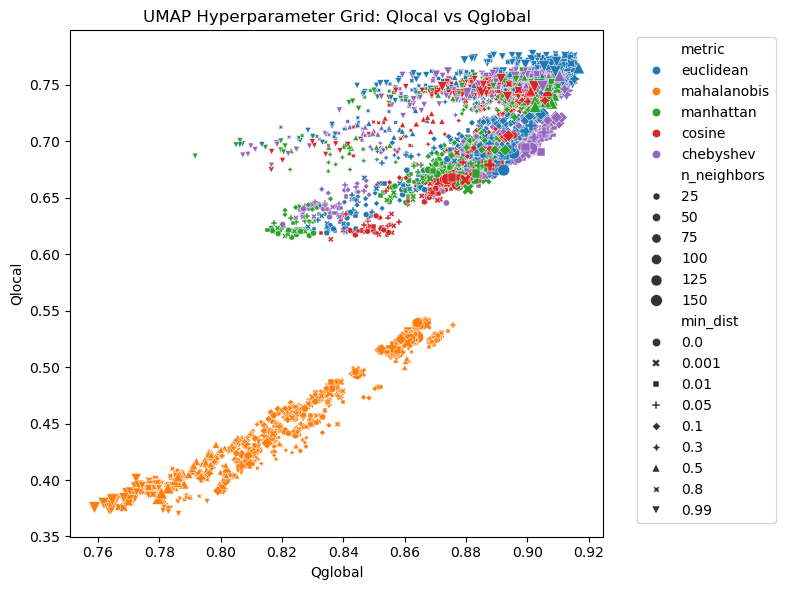

robust


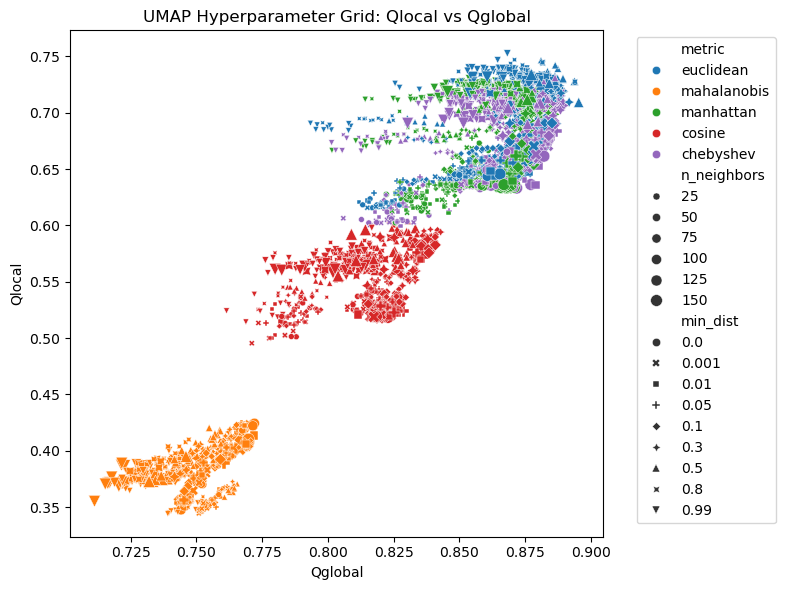

In [11]:
# Plot Qlocal vs Qglobal 

# Iterate over scalers
for scaler_name in df.scaler.unique():
    print(scaler_name)
    # Filter for scaler
    temp = df[df.scaler == scaler_name]

    # Take mean over iterations
    temp.drop("scaler", axis=1).groupby(["n_neighbors", "min_dist", "metric"]).mean().reset_index()
    
    # Plot Q
    plot_qs(temp, f"{config.output_dir_umap}/{scaler_name}/")
    plot_qs_interactive(temp, f"{config.output_dir_umap}/{scaler_name}/")

# Plotting with Final Hyperparameters

In [ ]:
# Define final hyperparameter combinations
final_hyps = {"minmax": {"n_neighbors": 50, "min_dist": 0.8, "metric": "euclidean", "n_components": 3}, 
              "robust": {"n_neighbors": 30, "min_dist": 0.99, "metric": "euclidean", "n_components": 3}}

# Iterate over scalers
metrics = {}
for scaler_name, hyps in final_hyps.items():
    print(scaler_name)
    df_temp = df_dict[scaler_name]
    X_temp = X_dict[scaler_name].to_numpy()

    # Compute embedding
    print("  Compute UMAP...")
    umap_model = UMAP(**hyps)
    embedding = umap_model.fit_transform(X_temp)

    # Save embedding
    df_temp[["e0", "e1", "e2"]] = embedding
    df_temp.to_csv(f"{config.output_dir_umap}/{scaler_name}/final_embeddings.csv")

    # Plot embedding
    print("  Plotting...")
    plot_embedding(embedding, save_as=f"{config.output_dir_umap}/{scaler_name}/final_embedding.png", dpi=1000, figsize=(6, 6))
    plot_interactive_embedding(df_temp)

    # Plot Shepard Diagram (on subset)
    # indices = np.random.default_rng().choice(X_temp.shape[0], size=4000, replace=False)
    #X_sub = X_temp[indices]
    #y_sub = embedding[indices]
    plot_shepard(X_temp, embedding, save_as=f"{config.output_dir_umap}/{scaler_name}/final_embedding_shepard.png", dpi=1000, figsize=(6, 6))